# Network Hive Plots: Structured Network Visualization

## Learning Objectives
By the end of this notebook, you will understand:
1. **What hive plots are** and why they're better than traditional network graphs
2. **When to use them** for network analysis
3. **How to create them** using Python
4. **How to interpret** patterns in hive plots

---

## What is a Hive Plot?

A **hive plot** is a rational approach to visualizing networks. Instead of letting nodes float randomly (like in force-directed graphs), nodes are placed on **linear axes** that radiate from a center point.

### The Problem with Traditional Network Graphs:
❌ **Random layouts** - Same network looks different each time
❌ **Hairball effect** - Large networks become unreadable tangles
❌ **No structure** - Hard to see patterns and groups
❌ **Not reproducible** - Can't compare networks reliably

### How Hive Plots Solve This:
✅ **Deterministic** - Same network always looks the same
✅ **Structured** - Nodes organized by meaningful properties
✅ **Scalable** - Works with large networks
✅ **Comparable** - Easy to compare different networks

### Key Concept:
Nodes are placed on **2-6 axes** based on their properties (e.g., type, degree, community). Position along each axis can represent another property (e.g., importance, size).

### When to Use Hive Plots:
- **Bipartite networks** - Two types of nodes (e.g., authors-papers, customers-products)
- **Tripartite networks** - Three types (e.g., genes-proteins-diseases)
- **Community detection** - Showing groups within networks
- **Comparing networks** - Before/after, different time periods
- **Large networks** - Where traditional graphs become hairballs

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Circle
import networkx as nx
from math import cos, sin, pi

# Set style
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries imported successfully!")
print("\n📚 We'll build hive plots from scratch to understand the concept.")

Libraries imported successfully!

📚 We'll build hive plots from scratch to understand the concept.


## Example 1: Simple Bipartite Hive Plot

Let's start with a **bipartite network** - two types of nodes (students and courses).

## Example 2: Comparison with Traditional Network Graph

Let's see why hive plots are better than traditional force-directed layouts.

/var/folders/8p/rzwrgzr95qngdjh40ggdxzf80000gn/T/ipykernel_96905/1200284305.py:68: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/8p/rzwrgzr95qngdjh40ggdxzf80000gn/T/ipykernel_96905/1200284305.py:68: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/andrearachetta/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/andrearachetta/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


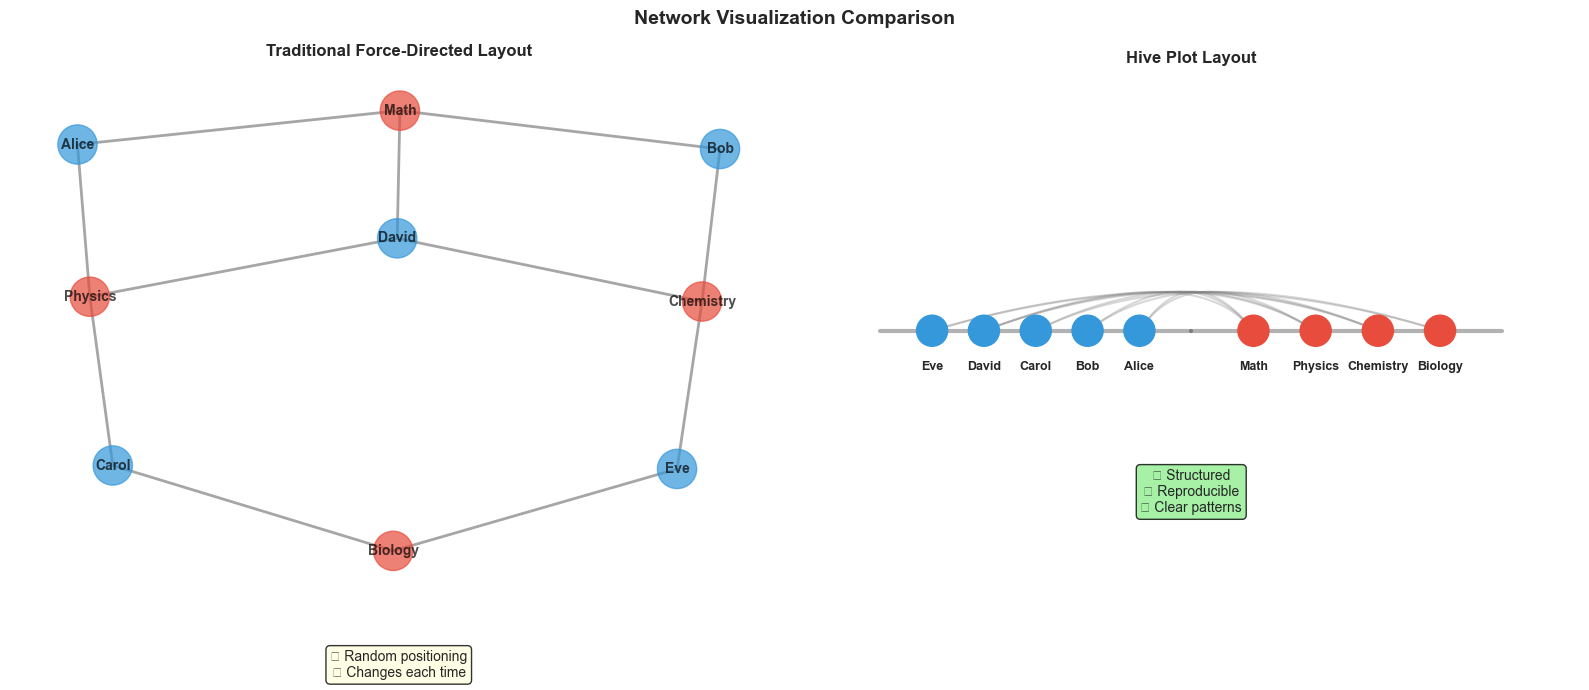


🎯 Why Hive Plots Win:
1. REPRODUCIBLE: Always looks the same
2. STRUCTURED: Clear organization
3. COMPARABLE: Easy to compare networks
4. SCALABLE: Works with large networks


In [3]:
# Create a network
G = nx.Graph()
G.add_edges_from(enrollments)

# Assign types
for node in students:
    G.nodes[node]['type'] = 'Student'
for node in courses:
    G.nodes[node]['type'] = 'Course'

# Side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Traditional layout
pos = nx.spring_layout(G, seed=42)
node_colors = ['#3498db' if G.nodes[n]['type'] == 'Student' else '#e74c3c' 
               for n in G.nodes()]
nx.draw(G, pos, ax=ax1, node_color=node_colors, node_size=800, 
        with_labels=True, font_size=10, font_weight='bold',
        edge_color='gray', width=2, alpha=0.7)
ax1.set_title('Traditional Force-Directed Layout', fontsize=12, fontweight='bold')
ax1.text(0.5, -0.15, '❌ Random positioning\n❌ Changes each time',
        transform=ax1.transAxes, ha='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Hive plot (simplified)
ax2.set_xlim(-1.5, 1.5)
ax2.set_ylim(-1, 1)
ax2.set_aspect('equal')
ax2.axis('off')

axis_length = 1.2
positions = {}

# Left axis
ax2.plot([-axis_length, 0], [0, 0], 'k-', linewidth=3, alpha=0.3)
for i, node in enumerate(students):
    x = -(i + 1) / (len(students) + 1) * axis_length
    positions[node] = (x, 0)
    circle = Circle((x, 0), 0.06, color='#3498db', zorder=3)
    ax2.add_patch(circle)
    ax2.text(x, -0.15, node, ha='center', fontsize=9, fontweight='bold')

# Right axis
ax2.plot([0, axis_length], [0, 0], 'k-', linewidth=3, alpha=0.3)
for i, node in enumerate(courses):
    x = (i + 1) / (len(courses) + 1) * axis_length
    positions[node] = (x, 0)
    circle = Circle((x, 0), 0.06, color='#e74c3c', zorder=3)
    ax2.add_patch(circle)
    ax2.text(x, -0.15, node, ha='center', fontsize=9, fontweight='bold')

# Edges
for edge in G.edges():
    x1, y1 = positions[edge[0]]
    x2, y2 = positions[edge[1]]
    t = np.linspace(0, 1, 100)
    x = (1-t)**2 * x1 + 2*(1-t)*t * 0 + t**2 * x2
    y = (1-t)**2 * y1 + 2*(1-t)*t * 0.3 + t**2 * y2
    ax2.plot(x, y, 'gray', alpha=0.3, linewidth=1.5, zorder=1)

ax2.set_title('Hive Plot Layout', fontsize=12, fontweight='bold')
ax2.text(0, -0.7, '✅ Structured\n✅ Reproducible\n✅ Clear patterns',
        ha='center', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.suptitle('Network Visualization Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🎯 Why Hive Plots Win:")
print("1. REPRODUCIBLE: Always looks the same")
print("2. STRUCTURED: Clear organization")
print("3. COMPARABLE: Easy to compare networks")
print("4. SCALABLE: Works with large networks")

## Example 3: Degree-Based Positioning

Position nodes along axes based on their **degree** (number of connections).

## Best Practices

### ✅ DO:
1. **Choose axes meaningfully** - Based on node types or communities
2. **Use position to encode info** - Degree, centrality, importance
3. **Keep it clean** - Use transparency, filter weak connections
4. **Document design** - Explain what axes and positions mean

### ❌ DON'T:
1. **Use for fully connected networks** - Too cluttered
2. **Mix unrelated types on same axis** - Keep axes homogeneous
3. **Use random positioning** - Defeats the purpose!

### 💡 Pro Tips:
- Start with 2 axes, add more if needed
- Try different positioning metrics
- Use hive plots to compare networks over time
- Combine with other visualizations

## Practice Exercise

In [5]:
# Practice: Create a hive plot for this collaboration network
researchers = ['Dr. A', 'Dr. B', 'Dr. C', 'Dr. D']
projects = ['Proj1', 'Proj2', 'Proj3']

collaborations = [
    ('Dr. A', 'Proj1'), ('Dr. A', 'Proj2'),
    ('Dr. B', 'Proj1'), ('Dr. B', 'Proj3'),
    ('Dr. C', 'Proj2'), ('Dr. C', 'Proj3'),
    ('Dr. D', 'Proj1')
]

print("📝 Your Task:")
print("Create a hive plot showing researcher-project collaborations")
print("\nQuestions to answer:")
print("1. Which researcher works on the most projects?")
print("2. Which project has the most researchers?")
print("3. Are there researchers who never collaborate?")

# Your code here!


📝 Your Task:
Create a hive plot showing researcher-project collaborations

Questions to answer:
1. Which researcher works on the most projects?
2. Which project has the most researchers?
3. Are there researchers who never collaborate?


## Summary

### Key Takeaways:
1. **Hive plots** organize networks on structured axes
2. **Better than force-directed** for reproducibility and clarity
3. **Position matters** - encode meaningful properties
4. **Best for** bipartite/tripartite networks and comparisons

### When to Use:
- Networks with distinct node types
- Need to compare multiple networks
- Large networks that become hairballs
- Want reproducible visualizations

### Resources:
- [Hive Plots Rational Network Visualization](http://www.hiveplot.com/)
- [NetworkX Documentation](https://networkx.org/)
- [Krzywinski et al. (2012) Hive Plots Paper](https://academic.oup.com/bib/article/13/5/627/412507)